In [55]:
import pandas as pd

df = pd.read_csv('../data/clean_dataset.csv')

print(f"DataFrame shape: {df.shape}")
print("\nDataFrame info:")
df.info()

print("\nMissing values:")
df.isnull().sum()

DataFrame shape: (234034, 22)

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 234034 entries, 0 to 234033
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       234034 non-null  float64
 1   HighBP                234034 non-null  float64
 2   HighChol              234034 non-null  float64
 3   CholCheck             234034 non-null  float64
 4   BMI                   234034 non-null  float64
 5   Smoker                234034 non-null  float64
 6   Stroke                234034 non-null  float64
 7   HeartDiseaseorAttack  234034 non-null  float64
 8   PhysActivity          234034 non-null  float64
 9   Fruits                234034 non-null  float64
 10  Veggies               234034 non-null  float64
 11  HvyAlcoholConsump     234034 non-null  float64
 12  AnyHealthcare         234034 non-null  float64
 13  NoDocbcCost           234034 non-null  float64
 14  GenHlth         

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Numerical features summary:
       Diabetes_binary         HighBP  ...      Education         Income
count    234034.000000  234034.000000  ...  234034.000000  234034.000000
mean          0.169450       0.457737  ...       4.975692       5.877582
std           0.375149       0.498212  ...       0.995056       2.096647
min           0.000000       0.000000  ...       1.000000       1.000000
25%           0.000000       0.000000  ...       4.000000       4.000000
50%           0.000000       0.000000  ...       5.000000       6.000000
75%           0.000000       1.000000  ...       6.000000       8.000000
max           1.000000       1.000000  ...       6.000000       8.000000

[8 rows x 22 columns]

Class distribution:


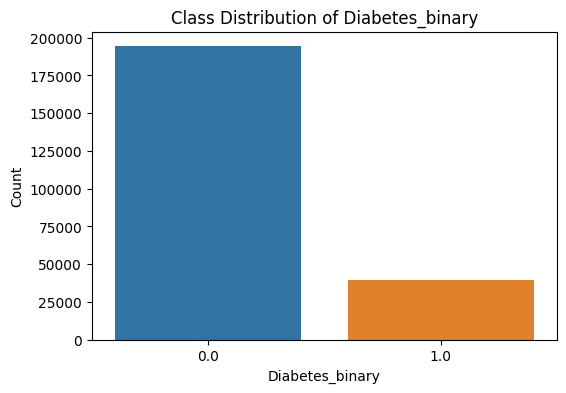

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nNumerical features summary:")
print(df.describe())

print("\nClass distribution:")
df['Diabetes_binary'].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diabetes_binary', hue='Diabetes_binary', legend=False)
plt.title('Class Distribution of Diabetes_binary')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.show()

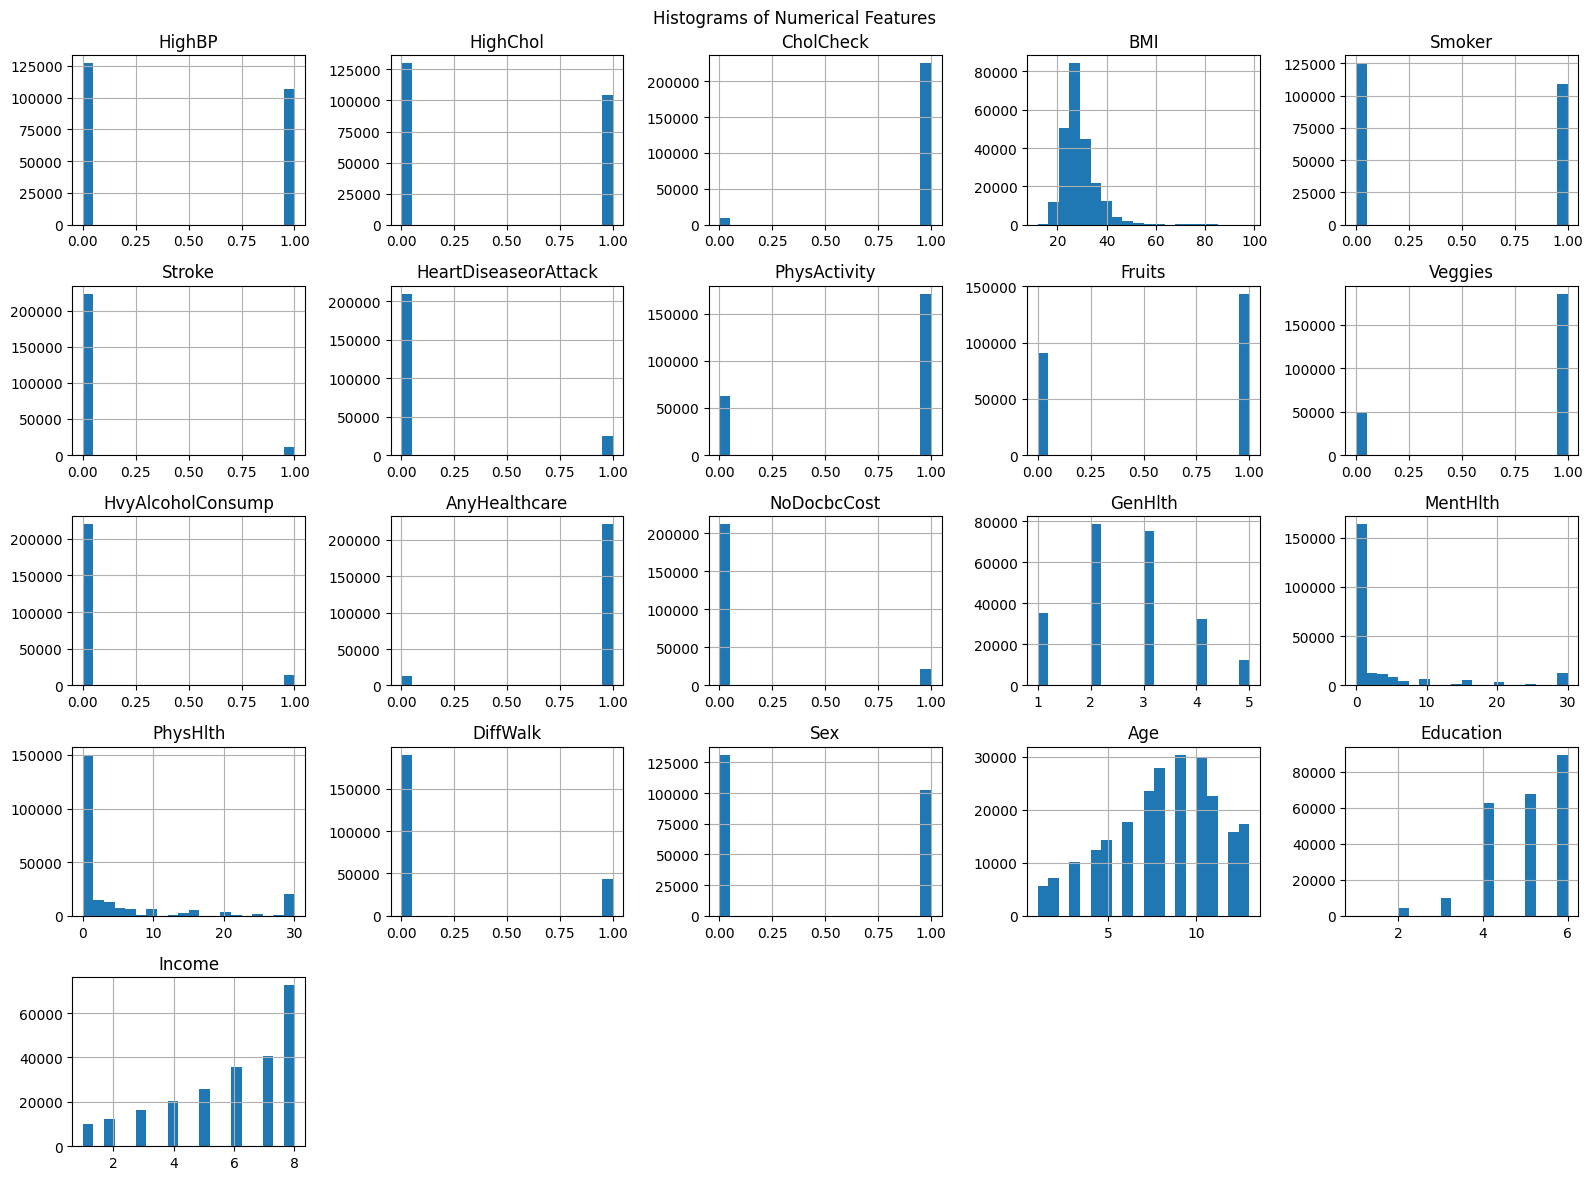

In [57]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.drop('Diabetes_binary')

df[numerical_features].hist(figsize=(16, 12), bins=20)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

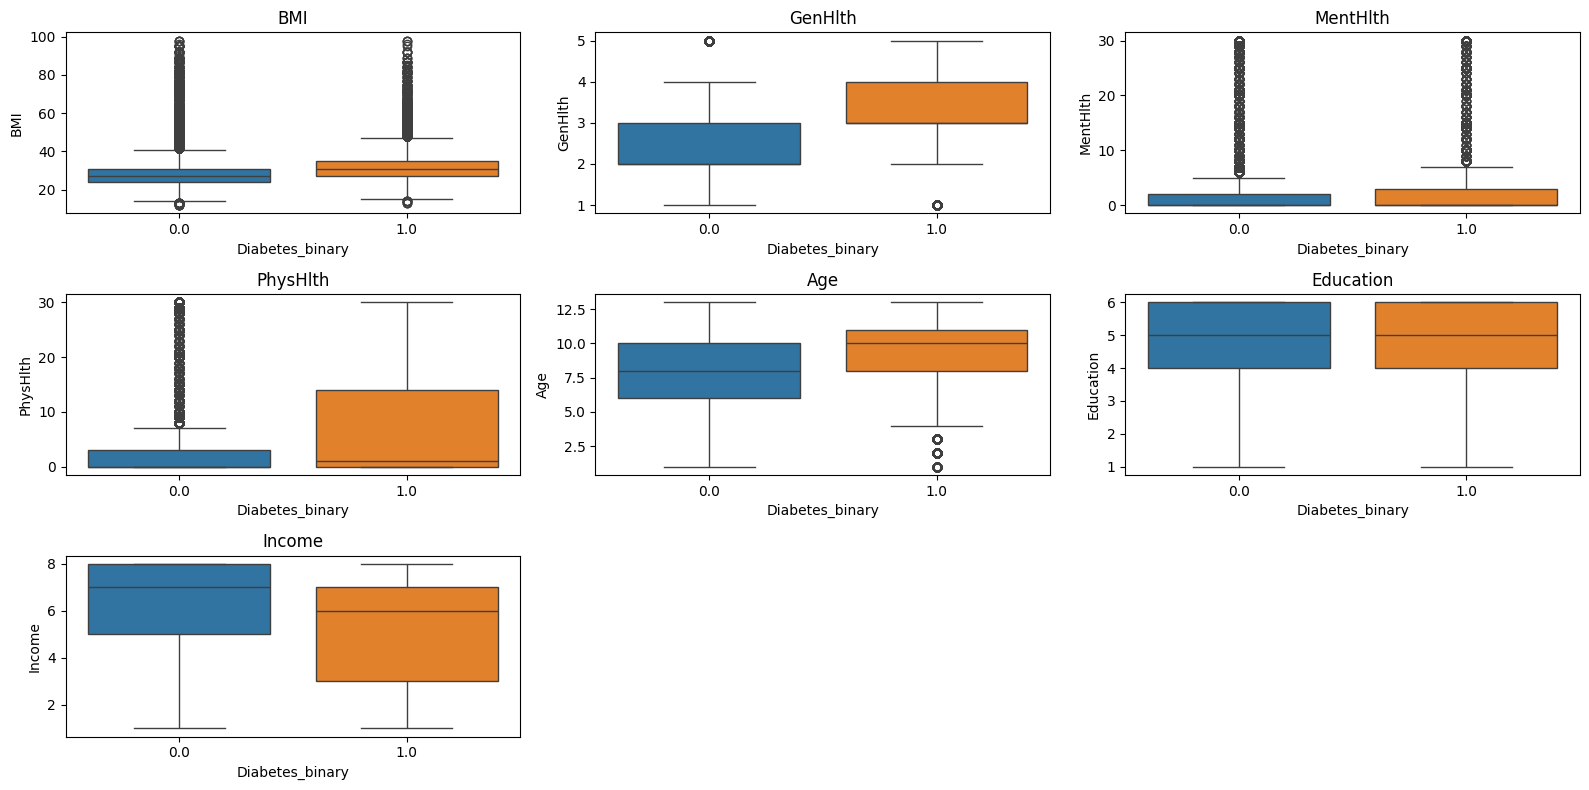

In [58]:
# Non binary features
features_to_plot = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

plt.figure(figsize=(16, 8))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Diabetes_binary', y=feature, hue='Diabetes_binary', legend=False)
    plt.title(feature)

plt.tight_layout()
plt.show()

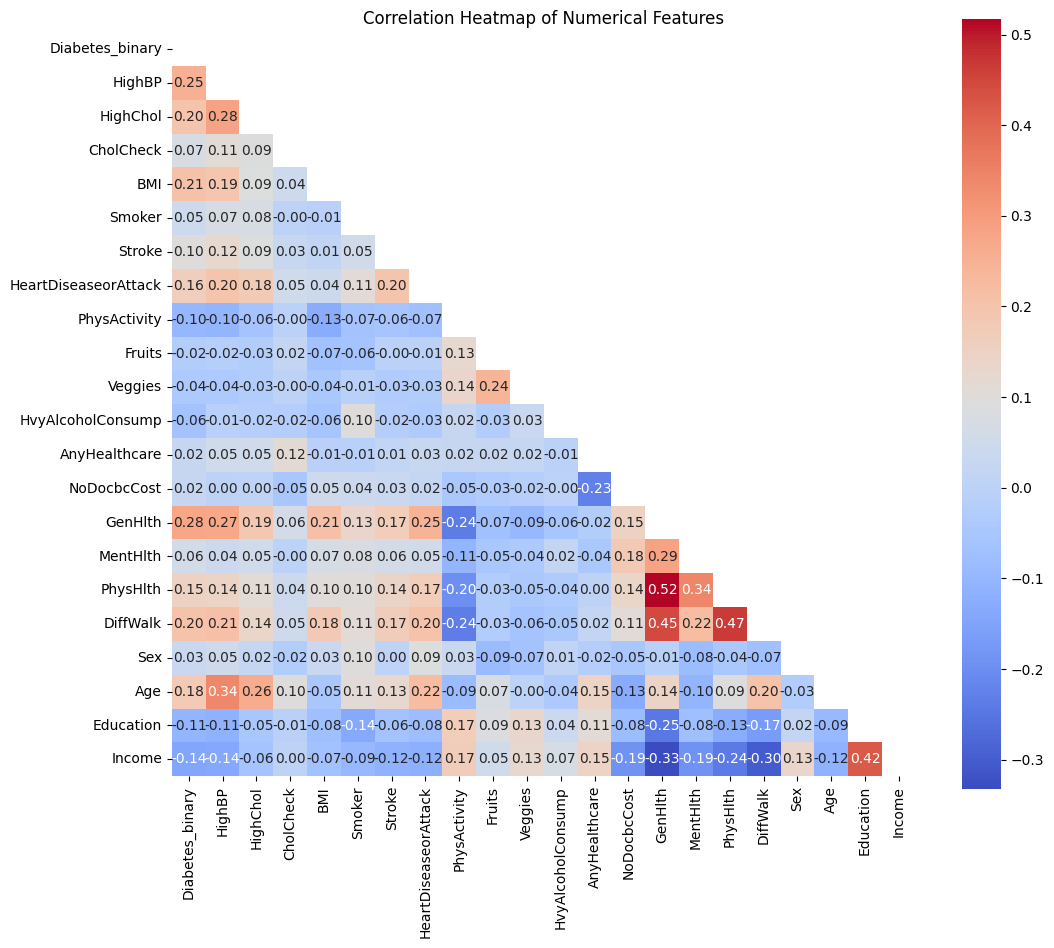

In [59]:
import numpy as np

plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, mask=mask)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [78]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (187227, 21)
Testing set shape: (46807, 21)


In [61]:
# Baseline models

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_baseline.fit(X_train, y_train)

print("Baseline models trained successfully.")

Baseline models trained successfully.


In [62]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"Evaluation for {model.__class__.__name__}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     38876
         1.0       0.39      0.18      0.24      7931

    accuracy                           0.81     46807
   macro avg       0.62      0.56      0.57     46807
weighted avg       0.77      0.81      0.78     46807

ROC AUC Score: 0.7369


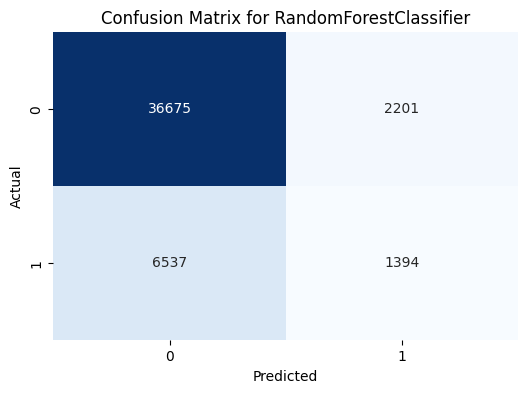

Evaluation for XGBClassifier:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     38876
         1.0       0.55      0.19      0.28      7931

    accuracy                           0.84     46807
   macro avg       0.70      0.58      0.59     46807
weighted avg       0.80      0.84      0.80     46807

ROC AUC Score: 0.7984


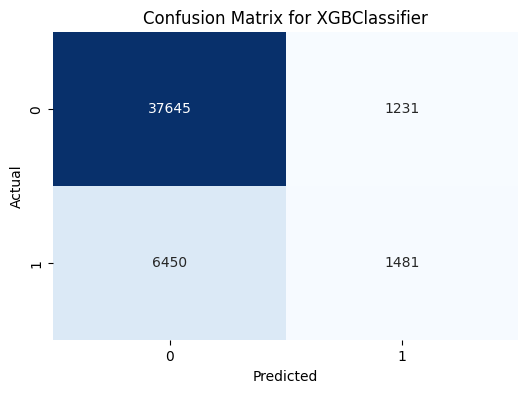

In [63]:
evaluate_model(rf_baseline, X_test, y_test)
evaluate_model(xgb_baseline, X_test, y_test)

In [64]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)

X_train_smote, y_train_smote = smoteenn.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Original class distribution:\n{y_train.value_counts()}")

print(f"SMOTEENN training set shape: {X_train_smote.shape}")
print(f"SMOTEENN class distribution:\n{y_train_smote.value_counts()}")

Original training set shape: (187227, 21)
Original class distribution:
Diabetes_binary
0.0    155501
1.0     31726
Name: count, dtype: int64
SMOTEENN training set shape: (217578, 21)
SMOTEENN class distribution:
Diabetes_binary
1.0    136363
0.0     81215
Name: count, dtype: int64


In [65]:
rf_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

xgb_smote = XGBClassifier(random_state=42, n_jobs=-1)
xgb_smote.fit(X_train_smote, y_train_smote)

print("Models trained on SMOTE data successfully.")

Models trained on SMOTE data successfully.


Evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

         0.0       0.92      0.75      0.82     38876
         1.0       0.35      0.66      0.46      7931

    accuracy                           0.73     46807
   macro avg       0.63      0.70      0.64     46807
weighted avg       0.82      0.73      0.76     46807

ROC AUC Score: 0.7763


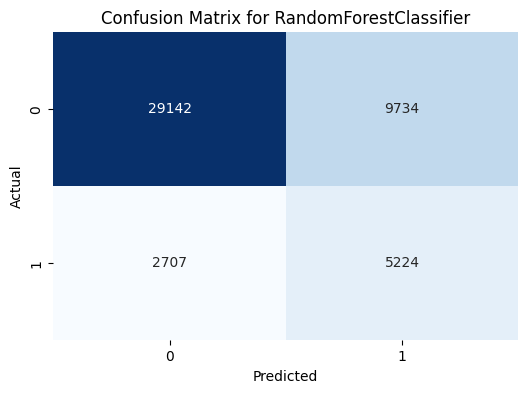

Evaluation for XGBClassifier:
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83     38876
         1.0       0.37      0.66      0.47      7931

    accuracy                           0.75     46807
   macro avg       0.64      0.71      0.65     46807
weighted avg       0.82      0.75      0.77     46807

ROC AUC Score: 0.7991


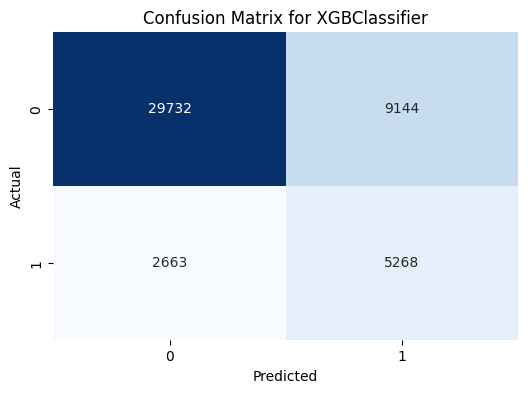

In [66]:
evaluate_model(rf_smote, X_test, y_test)
evaluate_model(xgb_smote, X_test, y_test)

In [67]:
def engineer_features(df_data):
    df_engineered = df_data.copy()

    # 1. Cardiovascular Risk Score 
    # Summing binary risk factors
    df_engineered['Cardio_Risk_Scoe'] = df_engineered[
        ['HighBP', 'HighChol', 'Smoker', 'HeartDiseaseorAttack', 'Stroke']
    ].sum(axis=1)

    # 2. Lifestyle Score
    # Positive factors: PhysActivity, Fruits, Veggies
    # Negative factors: HvyAlcoholConsump, Smoker
    df_engineered['Lifestyle_Score'] = (
        df_engineered[['PhysActivity', 'Fruits', 'Veggies']].sum(axis=1) - 
        df_engineered[['HvyAlcoholConsump', 'Smoker']].sum(axis=1)
    )

    # 3. Health Burden Score
    # Normalizing ordinal/continuous health metrics to roughly equal weights
    df_engineered['Health_Burden_Score'] = (
        df_engineered['GenHlth']/5.0 + 
        df_engineered['MentHlth']/30.0 + 
        df_engineered['PhysHlth']/30.0 + 
        df_engineered['DiffWalk']
    )

    return df_engineered

In [68]:
X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)

print(f"Orignal engineered training set shape: X={X_train_eng.shape}")
print(f"Original engineered training set class distribution:\n{y_train.value_counts()}")

smoteenn_eng = SMOTEENN(random_state=42)
X_train_eng_smote, y_train_eng_smote = smoteenn_eng.fit_resample(X_train_eng, y_train)

print(f"Engineered SMOTEENN training set shape: {X_train_eng_smote.shape}")
print(f"Engineered SMOTEENN class distribution:\n{y_train_eng_smote.value_counts()}")

Orignal engineered training set shape: X=(187227, 24)
Original engineered training set class distribution:
Diabetes_binary
0.0    155501
1.0     31726
Name: count, dtype: int64
Engineered SMOTEENN training set shape: (219747, 24)
Engineered SMOTEENN class distribution:
Diabetes_binary
1.0    136127
0.0     83620
Name: count, dtype: int64


Engineered features model trained successfully.
Evaluation for XGBClassifier:
              precision    recall  f1-score   support

         0.0       0.92      0.77      0.84     38876
         1.0       0.37      0.66      0.47      7931

    accuracy                           0.75     46807
   macro avg       0.64      0.71      0.66     46807
weighted avg       0.82      0.75      0.78     46807

ROC AUC Score: 0.7993


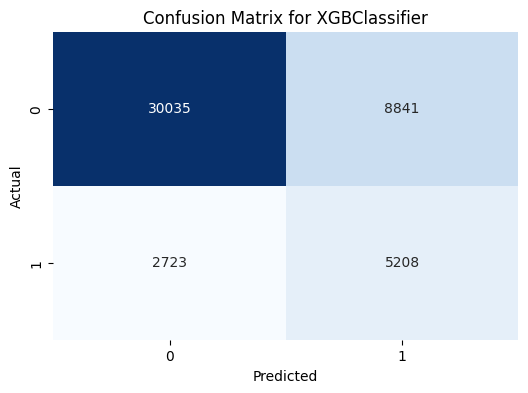

In [69]:
xgb_eng_smote = XGBClassifier(random_state=42, n_jobs=-1)
xgb_eng_smote.fit(X_train_eng_smote, y_train_eng_smote)

print("Engineered features model trained successfully.")

evaluate_model(xgb_eng_smote, X_test_eng, y_test)

In [80]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

pipeline = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, n_jobs=1))
])

param_grid_pipe = {
    'xgb__max_depth': [3, 5],             # Shallower trees often generalize better on synthetic data
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__n_estimators': [100, 200]
}

grid_search_pipe = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_pipe,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting grid search...")
grid_search_pipe.fit(X_train, y_train)

print("Grid search complete.")

Starting grid search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END xgb__learning_rate=0.1, xgb__max_depth=3, xgb__n_estimators=100; total time= 6.6min
[CV] END xgb__learning_rate=0.1, xgb__max_depth=3, xgb__n_estimators=100; total time= 6.6min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=100; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=200; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=100; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=100; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=200; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=200; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=100; total time= 6.7min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=10

Best parameters found: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Best realistic CV ROC AUC: 0.8031
Evaluation for Pipeline:
              precision    recall  f1-score   support

         0.0       0.93      0.74      0.82     38876
         1.0       0.35      0.71      0.47      7931

    accuracy                           0.73     46807
   macro avg       0.64      0.72      0.65     46807
weighted avg       0.83      0.73      0.76     46807

ROC AUC Score: 0.8025


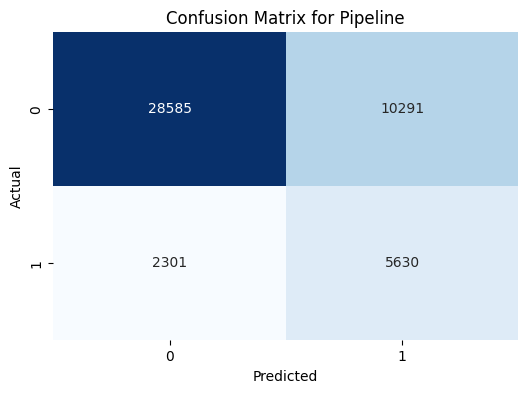

In [81]:
print(f"Best parameters found: {grid_search_pipe.best_params_}")
print(f"Best realistic CV ROC AUC: {grid_search_pipe.best_score_:.4f}")

best_xgb_leakfree = grid_search_pipe.best_estimator_
evaluate_model(best_xgb_leakfree, X_test, y_test)

Calculating SHAP values...
Generating SHAP Summary Plot...


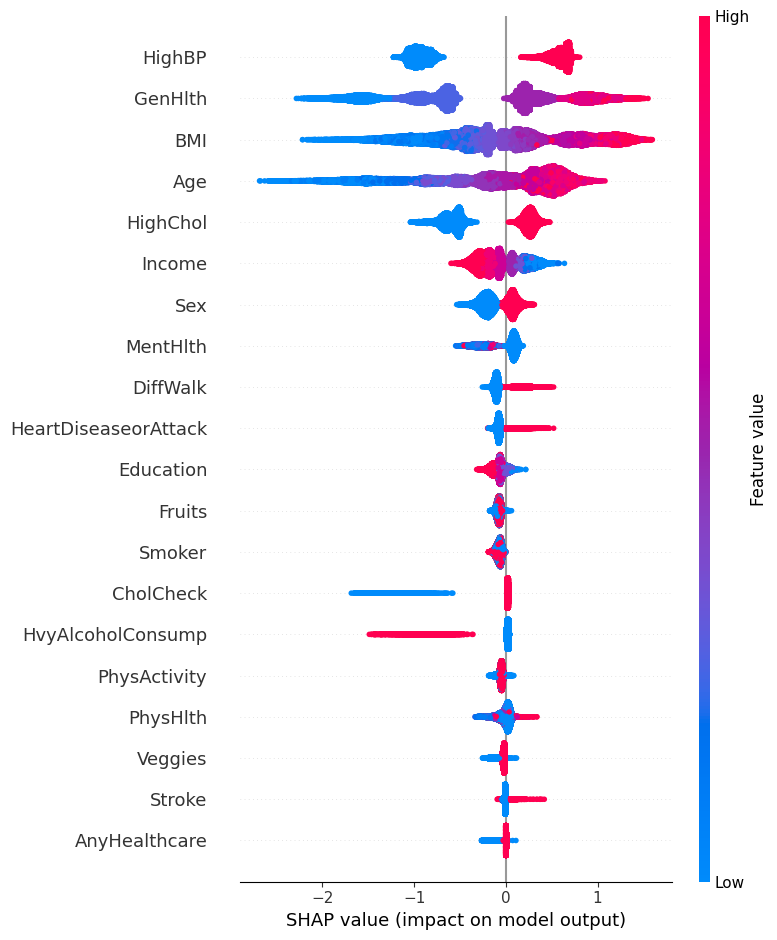

In [82]:
import shap

final_xgb_model = grid_search_pipe.best_estimator_.named_steps['xgb']

explainer = shap.TreeExplainer(final_xgb_model)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test)

print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test)